# Student Performance Indicator

## Problem Statement

The objective of this project is to understand how various factors influence students' academic performance.

Specifically, the project aims to analyze the relationship between students' test scores and the following features:

- Gender
- Race/Ethnicity
- Parental Level of Education
- Lunch Type
- Test Preparation Course

The project also involves building machine learning models to predict students' mathematics scores based on the available features.

In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set the default plotting style
sns.set_style("whitegrid")

# Display plots inside the notebook
%matplotlib inline

In [3]:
# ============================================================
# Load the Dataset
# ============================================================

# Read the dataset
df = pd.read_csv("study.csv")      # Change the file name if required

# Display the first five rows
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# ============================================================
# Dataset Overview
# ============================================================

# Display the number of rows and columns
print(f"Dataset Shape : {df.shape}")

# Display all column names
print("\nColumns in Dataset:")
print(df.columns.tolist())


Dataset Shape : (1000, 8)

Columns in Dataset:
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [5]:
# ============================================================
# Dataset Information
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
# ============================================================
# Statistical Summary
# ============================================================

# Numerical Features
display(df.describe())

# Categorical Features
display(df.describe(include="object"))

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [7]:
# ============================================================
# Data Quality Check
# ============================================================

# Missing Values
print("=" * 50)
print("Missing Values")
print("=" * 50)
display(df.isnull().sum())

# Duplicate Records
print("\n" + "=" * 50)
print("Duplicate Records")
print("=" * 50)
print(df.duplicated().sum())

# Unique Values
print("\n" + "=" * 50)
print("Unique Values")
print("=" * 50)
display(df.nunique())

Missing Values


gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


Duplicate Records
0

Unique Values


gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
columns = [
    "gender",
    "race_ethnicity",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course"
]

for col in columns:
    print(f"Categories in '{col}' variable: {df[col].unique()}\n")

Categories in 'gender' variable: <StringArray>
['female', 'male']
Length: 2, dtype: str

Categories in 'race_ethnicity' variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

Categories in 'parental_level_of_education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

Categories in 'lunch' variable: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

Categories in 'test_preparation_course' variable: <StringArray>
['none', 'completed']
Length: 2, dtype: str



In [9]:
# ============================================================
# Feature Engineering
# ============================================================

# Create Total Score
df["total_score"] = (
    df["math_score"] +
    df["reading_score"] +
    df["writing_score"]
)

# Create Average Score
df["average"] = df["total_score"] / 3

# Display the first five rows
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [10]:
# ============================================================
# Separate Numerical and Categorical Features
# ============================================================

# Numerical Features
num_features = df.select_dtypes(include="number").columns.tolist()

# Categorical Features
cat_features = df.select_dtypes(include="object").columns.tolist()

# Display the features
print("Numerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)

Numerical Features:
['math_score', 'reading_score', 'writing_score', 'total_score', 'average']

Categorical Features:
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of exploring and understanding the dataset through statistical summaries and visualizations.

The primary objectives are:

- Understand the distribution of the data.
- Detect outliers.
- Analyze relationships between variables.
- Identify patterns and trends.
- Generate insights before data preprocessing and model building.

## Univariate Analysis

Univariate Analysis focuses on examining one variable at a time.

The objectives are:

- Understand the distribution of numerical features.
- Detect potential outliers.
- Analyze the frequency distribution of categorical features.

### Distribution of Numerical Features

Histograms help visualize the distribution of numerical features.

They provide insights into:

- Data distribution
- Skewness
- Peaks
- Spread
- Possible outliers

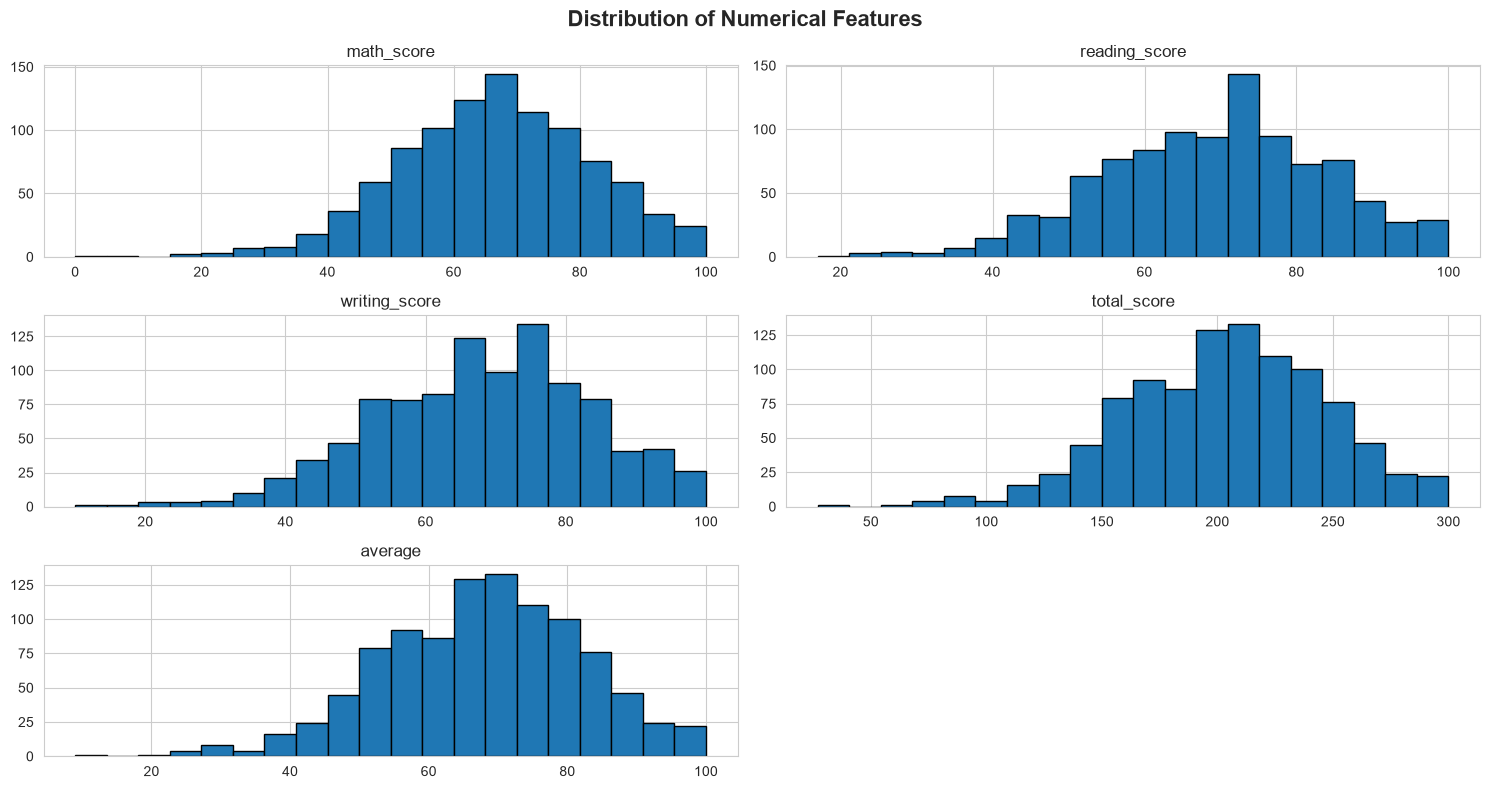

In [11]:
# ============================================================
# Distribution of Numerical Features
# ============================================================

# Create histograms for all numerical features
df[num_features].hist(
    figsize=(15, 8),
    bins=20,
    edgecolor="black"
)

# Add a common title
plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

# Adjust spacing
plt.tight_layout()

# Display plots
plt.show()

### Observation

- Most numerical features exhibit an approximately normal distribution.

- The majority of students scored within the middle range rather than at the extreme low or high ends.

- Reading and Writing scores appear slightly higher than Mathematics scores.

- No severe skewness is observed in the distributions.

### Boxplots of Numerical Features

Boxplots summarize the distribution of numerical features and help identify potential outliers.

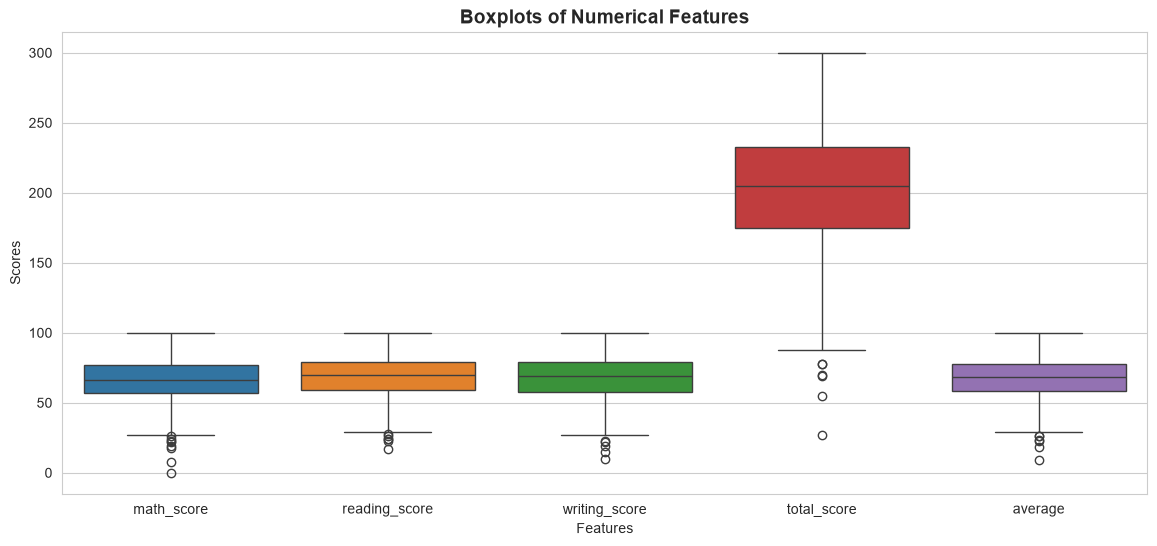

In [12]:
# ============================================================
# Boxplots of Numerical Features
# ============================================================

# Create the figure
plt.figure(figsize=(14, 6))

# Draw boxplots
sns.boxplot(data=df[num_features])

# Add title
plt.title(
    "Boxplots of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

# Label the axes
plt.xlabel("Features")
plt.ylabel("Scores")

# Display plot
plt.show()

### Distribution of Categorical Features

Count plots display the frequency of each category within the categorical features.

This helps understand the class distribution before analyzing their relationship with student performance.

In [13]:
# ============================================================
# Function to Plot Countplots
# ============================================================

def plot_countplots(data, columns):
    """
    Create count plots for multiple categorical features.
    """

    fig, axes = plt.subplots(3, 2, figsize=(18, 12))
    axes = axes.flatten()

    for ax, column in zip(axes, columns):

        sns.countplot(
            data=data,
            x=column,
            hue=column,
            palette="viridis",
            legend=False,
            ax=ax
        )

        # Display count labels
        for container in ax.containers:
            ax.bar_label(
                container,
                fontsize=10,
                padding=3
            )

        ax.set_title(
            f"{column.replace('_', ' ').title()}",
            fontsize=12,
            fontweight="bold"
        )

        ax.tick_params(axis="x", rotation=25)

    # Remove empty subplot
    if len(columns) < len(axes):
        fig.delaxes(axes[-1])

    plt.tight_layout()
    plt.show()

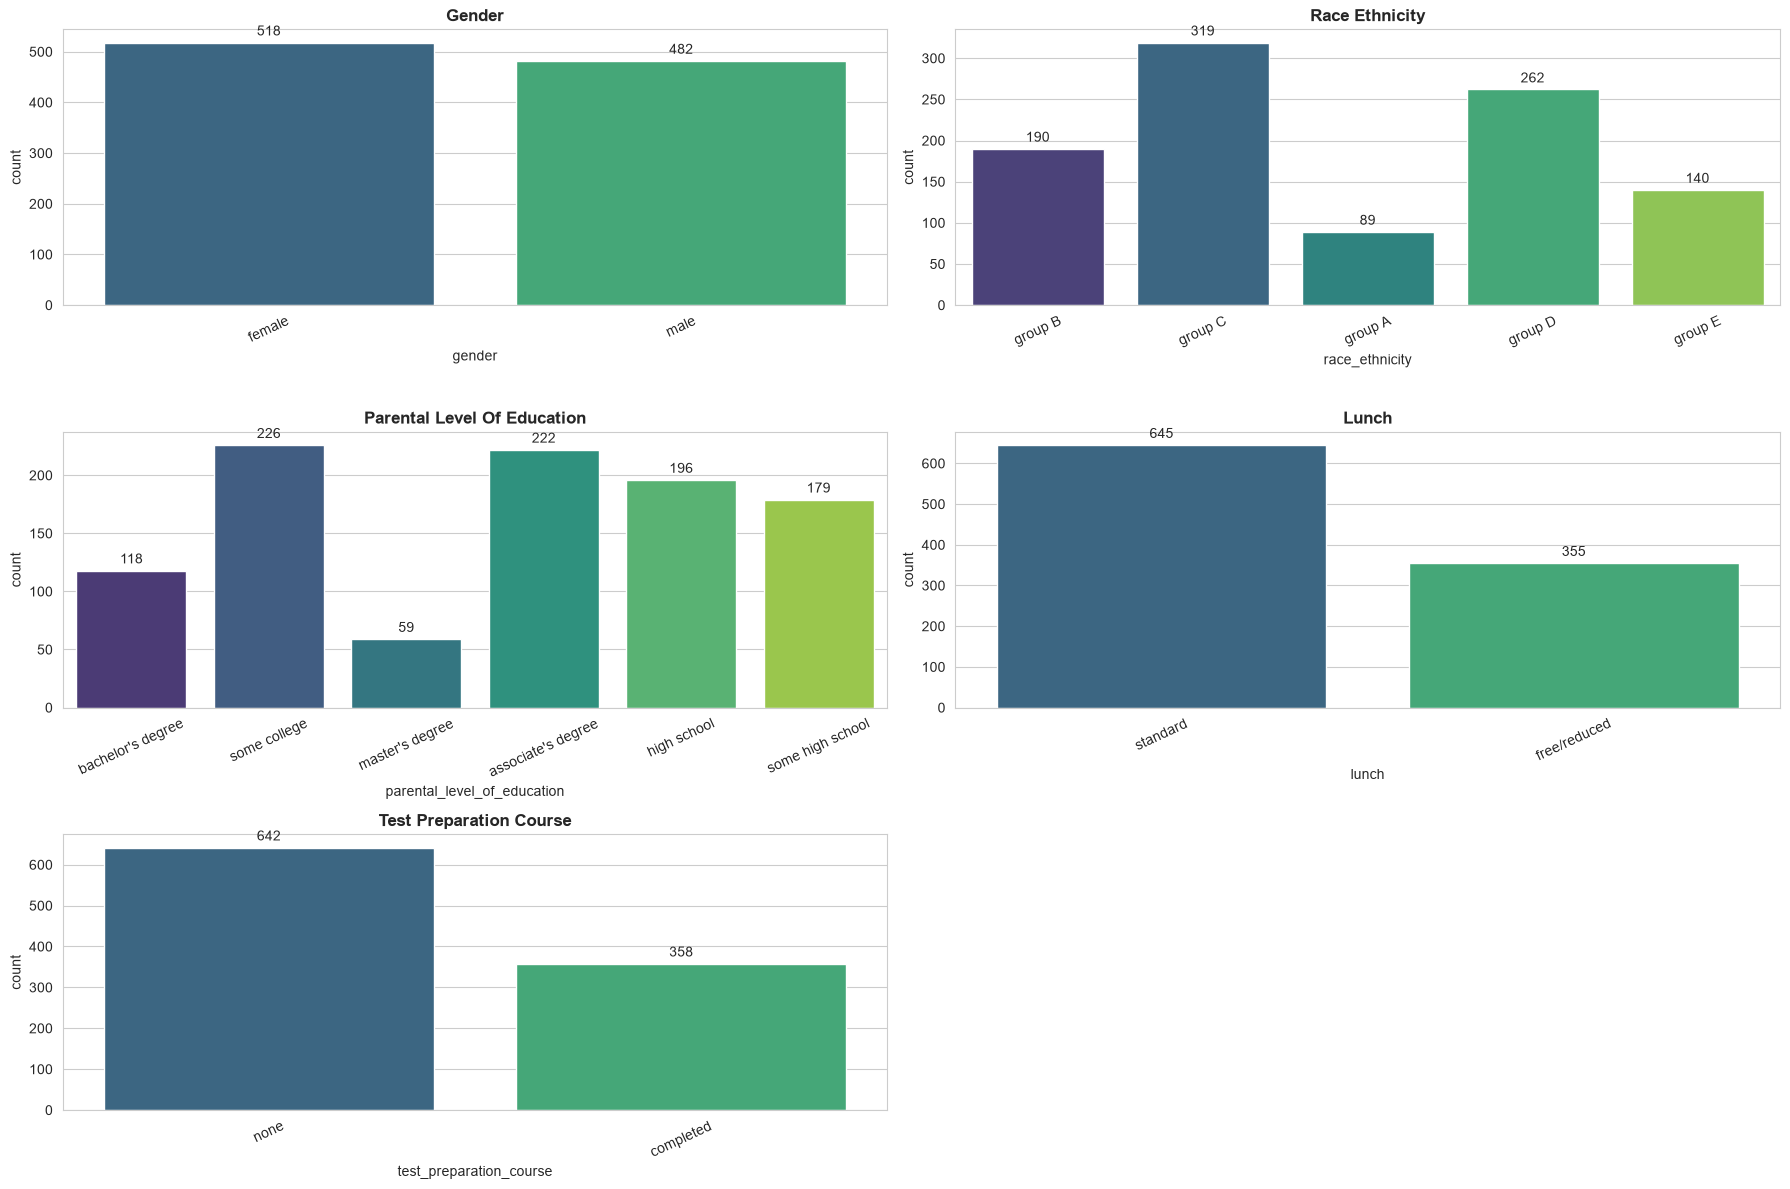

In [14]:
plot_countplots(df, cat_features)

## Bivariate Analysis

Bivariate Analysis examines the relationship between two variables.

In this project, we analyze how different categorical features are associated with students' average academic performance.

### Correlation Heatmap

A correlation heatmap illustrates the strength and direction of relationships between numerical features.

Correlation values range from **-1 to +1**:

- **+1** → Perfect Positive Correlation
- **0** → No Correlation
- **-1** → Perfect Negative Correlation

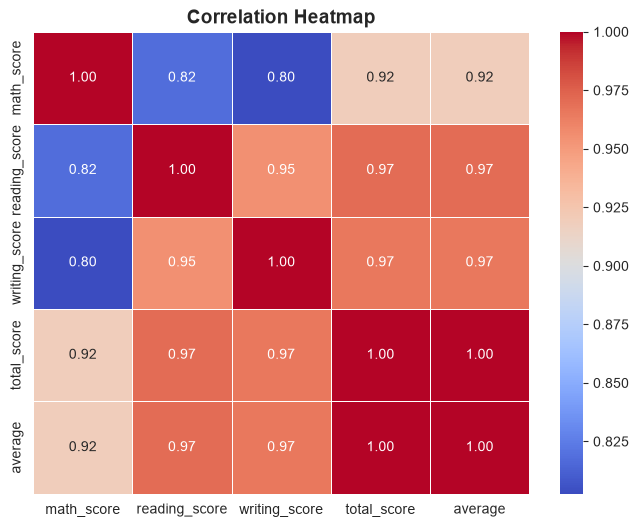

In [15]:
# ============================================================
# Correlation Heatmap
# ============================================================

# Compute the correlation matrix
correlation_matrix = df[num_features].corr()

# Create the figure
plt.figure(figsize=(8, 6))

# Draw the heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Add title
plt.title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight="bold"
)

# Display plot
plt.show()

### Observation

- Reading and Writing scores exhibit a very strong positive correlation.

- Mathematics also has a strong positive correlation with Reading and Writing.

- Total Score and Average Score have a perfect positive correlation because Average Score is directly calculated from Total Score.

- Overall, all numerical features are positively correlated.

In [16]:
# ============================================================
# Function to Plot Average Score by Categorical Feature
# ============================================================

def plot_average_score(data, feature):
    """
    Plot the average student score for a categorical feature.
    """

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=data,
        x=feature,
        y="average",
        hue=feature,
        palette="viridis",
        legend=False,
        errorbar=None
    )

    # Display values on top of bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=10,
            padding=3
        )

    plt.title(
        f"Average Score by {feature.replace('_', ' ').title()}",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Average Score")

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

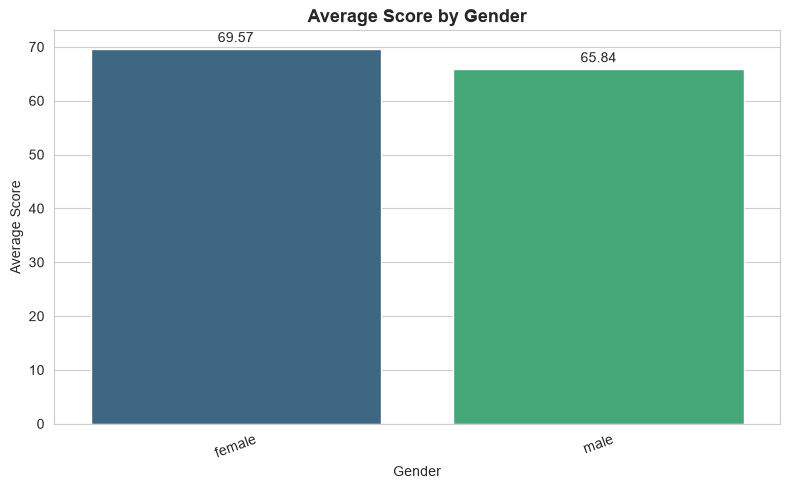

In [17]:
# ============================================================
# Average Score by Gender
# ============================================================

plot_average_score(df, "gender")

### Observation

- Female students achieved a higher average score than male students.

- The difference suggests that female students performed slightly better overall in this dataset.

- Gender appears to be associated with students' academic performance.

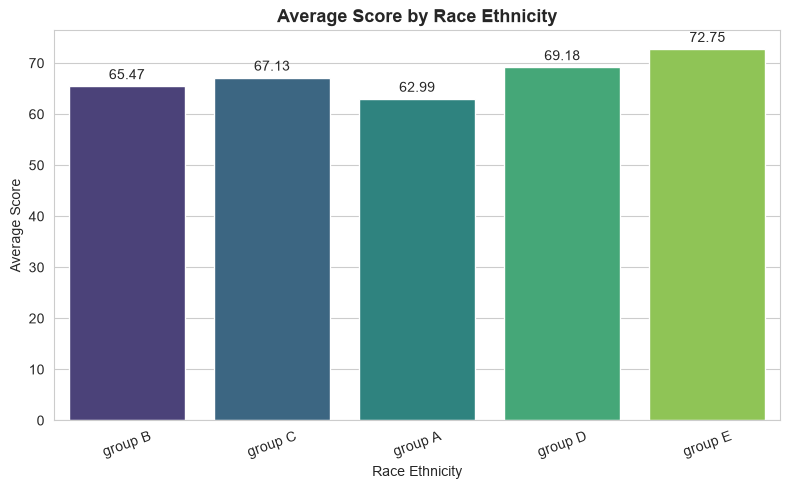

In [18]:
# ============================================================
# Average Score by Race/Ethnicity
# ============================================================

plot_average_score(df, "race_ethnicity")

### Observation

- Group E achieved the highest average score.

- Group A achieved the lowest average score.

- The average scores vary across race/ethnicity groups, indicating differences in academic performance.

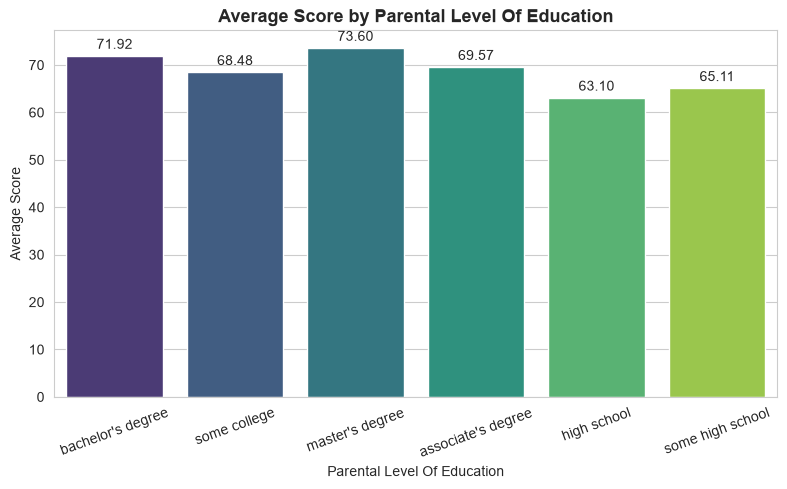

In [19]:
# ============================================================
# Average Score by Parental Level of Education
# ============================================================

plot_average_score(df, "parental_level_of_education")

### Observation

- Students whose parents hold a Master's degree achieved the highest average score.

- Students whose parents completed only High School achieved the lowest average score.

- Higher parental education levels appear to be associated with better student performance.

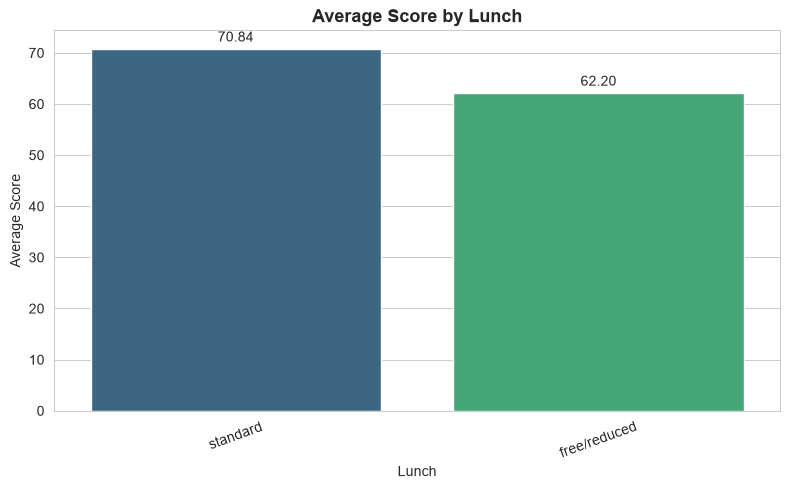

In [20]:
# ============================================================
# Average Score by Lunch Type
# ============================================================

plot_average_score(df, "lunch")

### Observation

- Students with a standard lunch achieved higher average scores than those receiving free/reduced lunch.

- The performance gap suggests that lunch type is associated with students' academic performance.

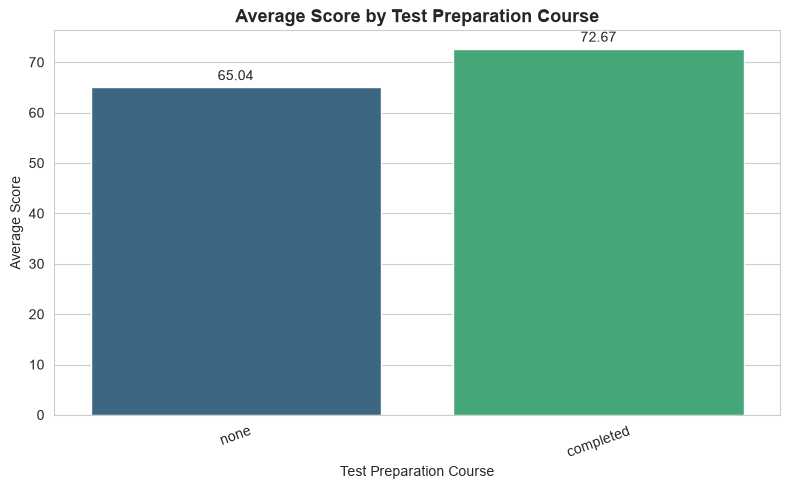

In [21]:
# ============================================================
# Average Score by Test Preparation Course
# ============================================================

plot_average_score(df, "test_preparation_course")

### Observation

- Students who completed the test preparation course achieved higher average scores than those who did not.

- The results suggest that completing the test preparation course is positively associated with overall student performance.

## Multivariate Analysis

Multivariate Analysis examines the relationship among multiple variables simultaneously.

In this project, we compare the average Mathematics, Reading, and Writing scores across different categorical features to identify performance patterns.

In [22]:
# ============================================================
# Function to Plot Subject-wise Performance
# ============================================================

def plot_subject_scores(data, feature):
    """
    Plot subject-wise average scores for a categorical feature.
    """

    # Convert the dataset from wide format to long format
    subject_scores = data.melt(
        id_vars=feature,
        value_vars=["math_score", "reading_score", "writing_score"],
        var_name="Subject",
        value_name="Score"
    )

    # Create the figure
    plt.figure(figsize=(10, 6))

    # Draw grouped bar plot
    ax = sns.barplot(
        data=subject_scores,
        x="Subject",
        y="Score",
        hue=feature,
        palette="Set2",
        errorbar=None
    )

    # Display values on top of each bar
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=9,
            padding=3
        )

    # Add title
    plt.title(
        f"Subject-wise Average Scores by {feature.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold"
    )

    # Label the axes
    plt.xlabel("Subjects")
    plt.ylabel("Average Score")

    # Display legend
    plt.legend(title=feature.replace("_", " ").title())

    plt.tight_layout()
    plt.show()

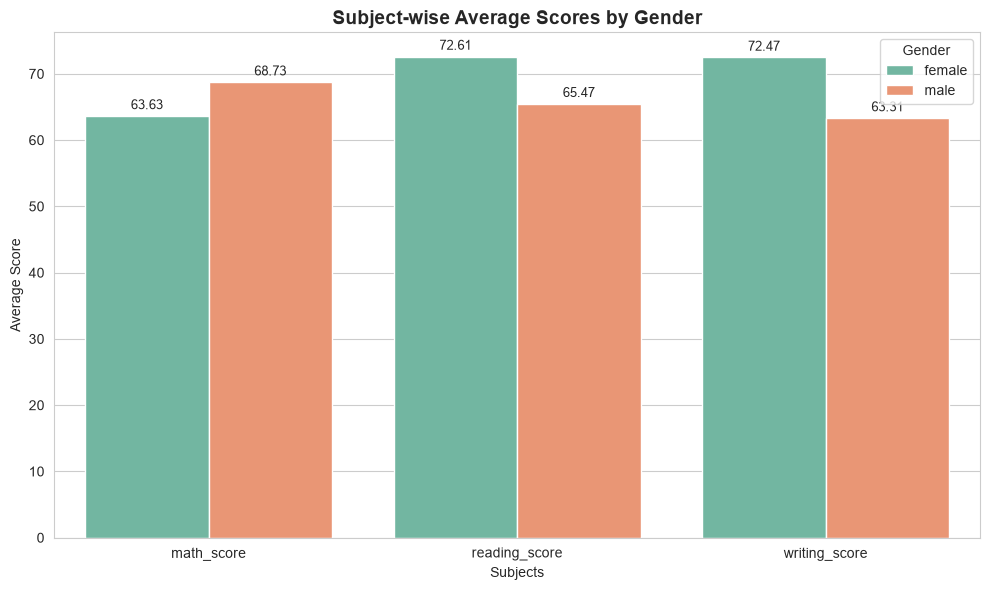

In [23]:
# ============================================================
# Subject-wise Performance by Gender
# ============================================================

plot_subject_scores(df, "gender")

### Observation

- Male students achieved higher average scores in Mathematics.

- Female students achieved higher average scores in Reading and Writing.

- Female students generally performed better in language-related subjects, while male students performed slightly better in Mathematics.

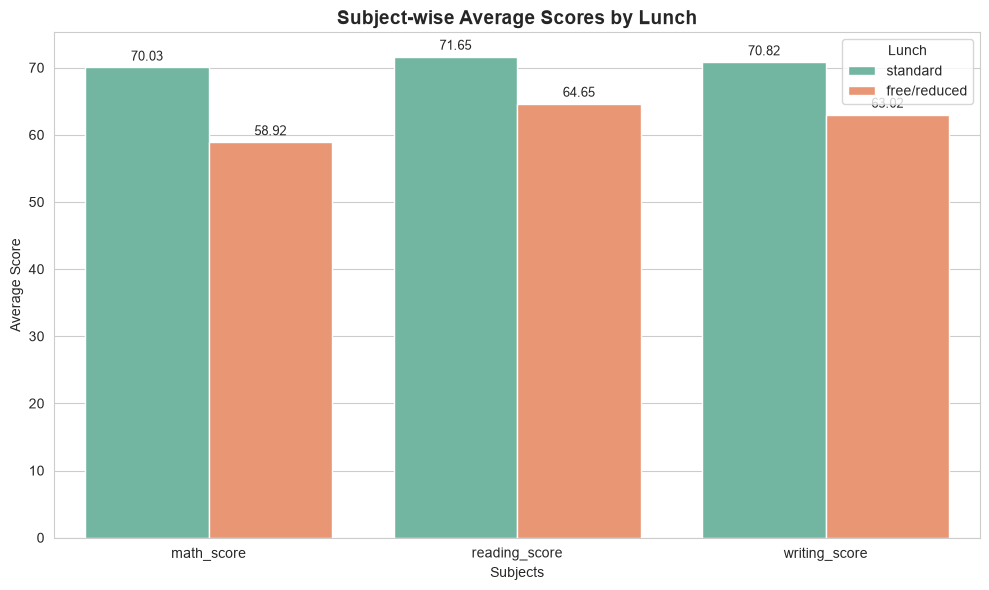

In [24]:
# ============================================================
# Subject-wise Performance by Lunch Type
# ============================================================

plot_subject_scores(df, "lunch")

### Observation

- Students with a standard lunch achieved higher scores in all three subjects.

- The largest performance gap is observed in Mathematics.

- Students receiving free/reduced lunch consistently scored lower across all subjects.

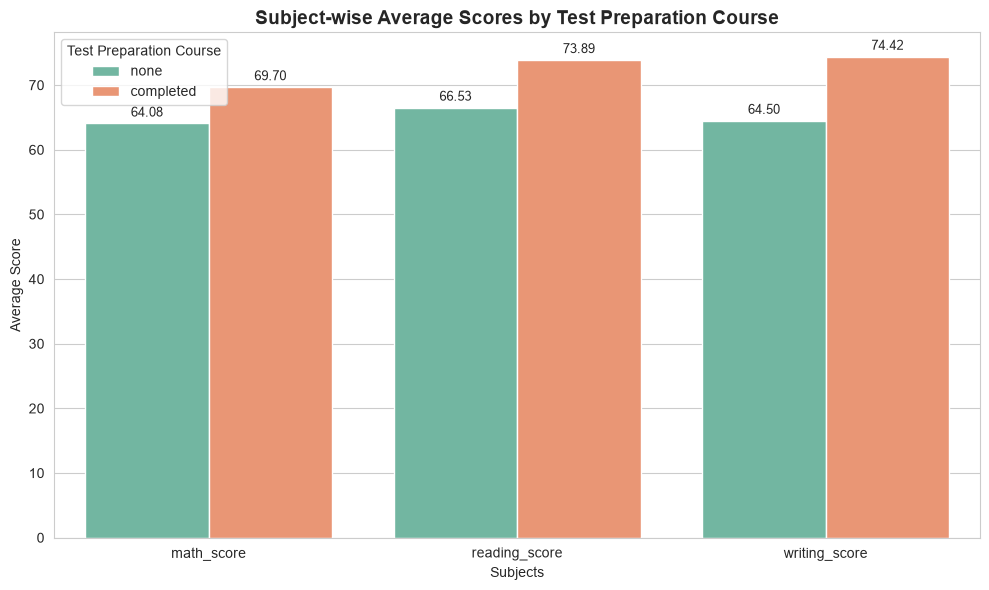

In [25]:
# ============================================================
# Subject-wise Performance by Test Preparation Course
# ============================================================

plot_subject_scores(df, "test_preparation_course")

### Observation

- Students who completed the test preparation course achieved higher scores in Mathematics, Reading, and Writing.

- The largest improvement is observed in Writing, followed by Reading.

- Completing the test preparation course is positively associated with better academic performance across all three subjects.

# Key Insights from Exploratory Data Analysis

1. The numerical features are approximately normally distributed.

2. No significant outliers were observed in the numerical features.

3. Reading and Writing scores exhibit a very strong positive correlation.

4. Female students generally outperform male students in Reading and Writing, while male students perform slightly better in Mathematics.

5. Students from Race/Ethnicity Group E achieved the highest average score, whereas Group A achieved the lowest.

6. Students whose parents have a Master's degree achieved the highest average scores.

7. Students with Standard Lunch consistently outperformed students receiving Free/Reduced Lunch.

8. Students who completed the Test Preparation Course consistently achieved higher scores across all three subjects.

9. Lunch Type and Test Preparation Course show the strongest association with students' academic performance.

10. Overall, Gender, Race/Ethnicity, Parental Level of Education, Lunch Type, and Test Preparation Course all appear to be associated with differences in student performance.